# **Exercise 1 : Use the openpyxl module to create a new workbook and add values/formulas to it**

In [1]:
import openpyxl

# 1. Create a new workbook
workbook = openpyxl.Workbook()
sheet = workbook.active

# 2. Add values
sheet['A1'] = 'First number ==> '
sheet['B1'] = 2
sheet['A2'] = 'Second number ==> '
sheet['B2'] = 8

# 3. Add a formula
sheet['A3'] = 'Result'
sheet['B3'] = '=B1*B2'

# 4. Save the workbook
workbook.save('simple_calculator.xlsx')

print("simple_calculator.xlsx has been created. Open it in Excel to check the calculator.")

# 5. Close the workbook
# workbook.close()

simple_calculator.xlsx has been created. Open it in Excel to check the calculator.


# **Exercise 2 : Open an Excel workbook and read down a list of plants finding the ones not in stock**

In [4]:
import sys
sys.path.append(r"C:\wiseowl\Python\Courseware\Lib\site-packages")

# work with Excel
from openpyxl import load_workbook

# create a new workbook
plant_book = plant_book = load_workbook(filename='Plants.xlsx')

# get reference to first (and only) sheet
plant_sheet = plant_book["Sheet1"]

# keep looping down cells in first column
this_plant = plant_sheet.cell(1,1)

int_check = 0
while True:

    # avoid infinite loops if bug
    int_check += 1
    if int_check > 100:
        print("Integer check triggered")
        break

    # go to next plant
    this_plant = this_plant.offset(1,0)

    # if no such plant, stop
    if this_plant.value == None:
        print("\nThe above plants are not in stock")
        break

    # if this plant is not in stock, say so
    stock_cell = this_plant.offset(0,7)
    if stock_cell.value == "No":
        print(this_plant.value)

# close down the file
plant_book.close()

Honeysuckle
Lupin
Skimmia
Rosa
Gladioli

The above plants are not in stock


/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


# **Exercise 3 : Load Excel File and Write the Data. From this file, do the following tasks : Load Excel File and give path to your file, Perform data manipulation on the DataFrame by filtering the data where ‘Sales’ is greater than 1000. Use Openpyxl to write the filtered data back to the Excel file**

In [5]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows

# 1. Load Excel File and give path to your file
file_path = 'data.xlsx'  # Changed the file path to 'data.xlsx'

try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please check the file path.")
    exit()

# 2. Perform data manipulation on the DataFrame by filtering the data where ‘Sales’ is greater than 1000.
filtered_df = df[df['Sales'] > 1000]

# 3. Use Openpyxl to write the filtered data back to the Excel file

# Load the existing workbook
try:
    workbook = load_workbook(file_path)
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please check the file path.")
    exit()

# Select the active worksheet
worksheet = workbook.active

# Clear the existing content
worksheet.delete_rows(1, worksheet.max_row)

# Write the header of the filtered DataFrame
for col_num, value in enumerate(filtered_df.columns, 1):
    cell = worksheet.cell(row=1, column=col_num, value=value)

# Write the data of the filtered DataFrame
for row_num, row_data in enumerate(dataframe_to_rows(filtered_df, header=False, index=False), 2):
    for col_num, value in enumerate(row_data, 1):
        cell = worksheet.cell(row=row_num, column=col_num, value=value)

# Save the changes back to the same Excel file
try:
    workbook.save(file_path)
    print(f"Filtered data (Sales > 1000) has been written back to '{file_path}'.")
except Exception as e:
    print(f"An error occurred while saving the Excel file: {e}")
finally:
    workbook.close()

Filtered data (Sales > 1000) has been written back to 'data.xlsx'.


Sales report has been exported to 'sales_report.xlsx'.


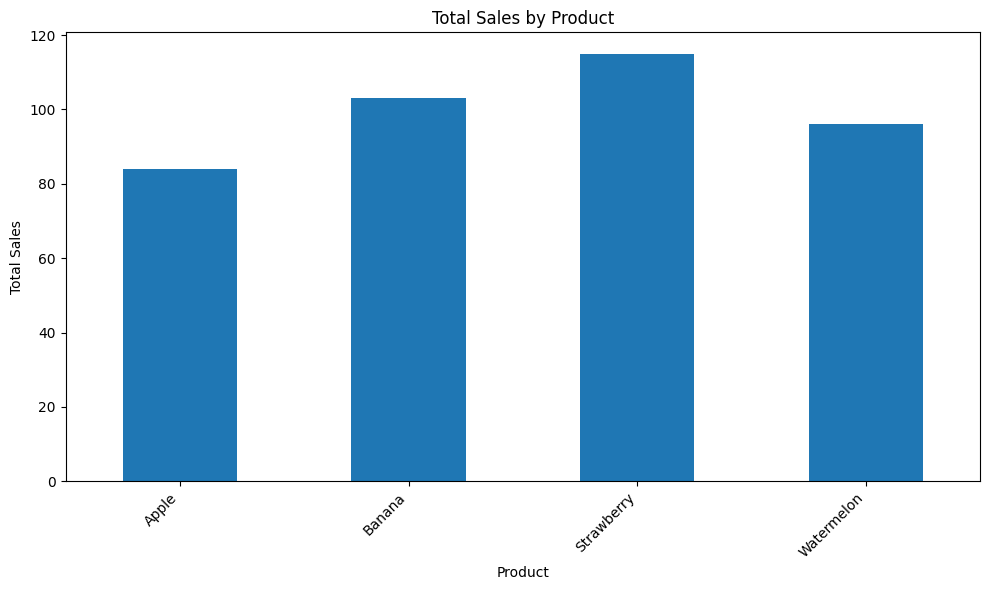

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read data from the Excel file productSales.xlsx
file_path = 'productSales.xlsx'

try:
    df = pd.read_excel(file_path)
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'. Please check the file path.")
    exit()

# 2. Manipulate the data by grouping by ‘product’ and summing the sales
grouped_sales = df.groupby('product')['sales'].sum()

# 3. Export the grouped sales data back into a new Excel file (‘sales_report.xlsx’)
output_file_path = 'sales_report.xlsx'

try:
    grouped_sales.to_excel(output_file_path, sheet_name='SalesReport')
    print(f"Sales report has been exported to '{output_file_path}'.")
except Exception as e:
    print(f"An error occurred while exporting to Excel: {e}")

# 4. Plot a simple bar chart (optional, but good for visualizing the result)
plt.figure(figsize=(10, 6))
grouped_sales.plot(kind='bar')
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()